In [2]:
import pandas as pd 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import re 
import string
import contractions
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
df = pd.read_csv("eng_dataset.csv")
df.head(10)

,ID,sentiment,content
0,10941,anger,At the point today where if someone says somet...
1,10942,anger,@CorningFootball IT'S GAME DAY!!!! T MIN...
2,10943,anger,This game has pissed me off more than any othe...
3,10944,anger,@spamvicious I've just found out it's Candice ...
4,10945,anger,@moocowward @mrsajhargreaves @Melly77 @GaryBar...
5,10946,anger,@moocowward @mrsajhargreaves @Melly77 @GaryBar...
6,10947,anger,wanna go home and focus up on this game . Don'...
7,10948,anger,@virginmedia I've been disconnected whilst on ...
8,10949,anger,@virginmedia I've been disconnected whilst on ...
9,10950,anger,I wanna see you smile I don't wanna see you ma...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7102 entries, 0 to 7101
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         7102 non-null   int64 
 1   sentiment  7102 non-null   object
 2   content    7102 non-null   object
dtypes: int64(1), object(2)
memory usage: 166.6+ KB


In [5]:
print(df.shape)

(7102, 3)


In [6]:
df.isnull().sum()

ID           0
sentiment    0
content      0
dtype: int64

In [7]:
df['sentiment'].value_counts()

sentiment
fear       2252
anger      1701
joy        1616
sadness    1533
Name: count, dtype: int64

In [8]:
print("Before:", df.shape)

df = df.drop_duplicates(subset=["content", "sentiment"])

print("After:", df.shape)

Before: (7102, 3)
After: (7102, 3)


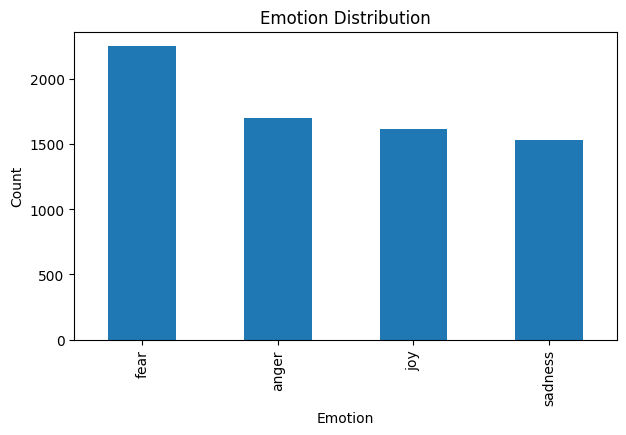

In [9]:
# import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [10]:
df["text_length"] = df["content"].apply(lambda x: len(str(x).split()))

In [11]:
df['text_length'].describe()

count    7102.000000
mean       16.081808
std         6.610318
min         1.000000
25%        11.000000
50%        17.000000
75%        22.000000
max        33.000000
Name: text_length, dtype: float64

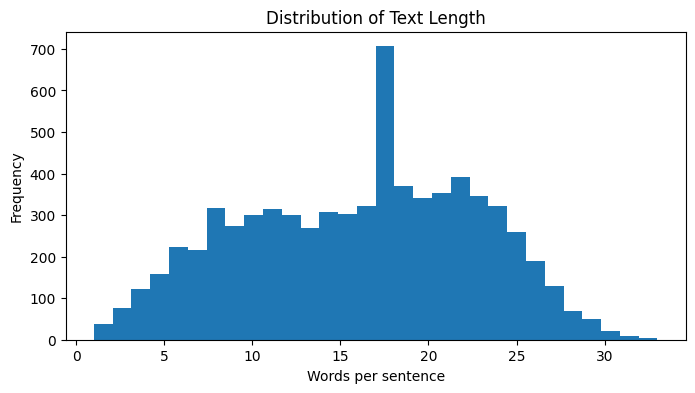

In [12]:
plt.figure(figsize=(8,4))
plt.hist(df["text_length"], bins=30)
plt.xlabel("Words per sentence")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length")
plt.show()

In [13]:
for emotion in df["sentiment"].unique():
    print("="*50)
    print(emotion)
    print(df[df["sentiment"] == emotion]["content"].iloc[0])

anger
At the point today where if someone says something remotely kind to me, a waterfall will burst out of my eyes
fear
#Matthew 25; 1-13\nCould somebody shoot a #video about it?\nIt could be 1 of those #horror videos but in the same time turning many 2 #Christ
joy
You must be knowing #blithe means (adj.)  Happy, cheerful.
sadness
My 2 teens sons just left in the car to get haircuts. I'm praying up a storm that they make it home safely!! #sad #TerenceCrutcher


In [14]:
# import re
# import string
# import contractions

def clean_text(text):
    text = text.lower()

    # expand contractions
    text = contractions.fix(text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # keep hashtag words
    text = text.replace('#', '')

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove non-English / emoji artifacts
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
df['clean_text'] = df['content'].apply(clean_text)

In [16]:
# text length in words
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print(df['text_length'].describe())

count    7102.000000
mean       15.561954
std         6.797618
min         1.000000
25%        10.000000
50%        16.000000
75%        21.000000
max        34.000000
Name: text_length, dtype: float64


In [17]:
df.head(10)

,ID,sentiment,content,text_length,clean_text
0,10941,anger,At the point today where if someone says somet...,21,at the point today where if someone says somet...
1,10942,anger,@CorningFootball IT'S GAME DAY!!!! T MIN...,7,it is game day t minus relentless
2,10943,anger,This game has pissed me off more than any othe...,23,this game has pissed me off more than any othe...
3,10944,anger,@spamvicious I've just found out it's Candice ...,19,i have just found out it is candice and not ca...
4,10945,anger,@moocowward @mrsajhargreaves @Melly77 @GaryBar...,16,if he cannot come to my muma th after k tweets...
5,10946,anger,@moocowward @mrsajhargreaves @Melly77 @GaryBar...,17,if he cannot come to my muma th after k tweets...
6,10947,anger,wanna go home and focus up on this game . Don'...,17,want to go home and focus up on this game do n...
7,10948,anger,@virginmedia I've been disconnected whilst on ...,18,i have been disconnected whilst on holiday but...
8,10949,anger,@virginmedia I've been disconnected whilst on ...,17,i have been disconnected whilst on holiday but...
9,10950,anger,I wanna see you smile I don't wanna see you ma...,16,i want to see you smile i do not want to see y...


In [18]:
X = df["clean_text"]
y = df["sentiment"]

### TF-IDF Vectorization

In [19]:
label_encoder = LabelEncoder()

tfidf = TfidfVectorizer(
    max_features=1500,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2),
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(X)
y_encoded = label_encoder.fit_transform(y)

## Data Spliting

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Train Linear SVM model

In [21]:
linearSVC_model = LinearSVC( C=1 , max_iter=2000)
linearSVC_model.fit(X_train, y_train)

LinearSVC(C=1, max_iter=2000)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

model_results = []

def add_result(model_name, y_true, y_pred):
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted")
    })

### Evaluation Linear Model performance

In [23]:
y_pred = linearSVC_model.predict(X_test)
y_pred
add_result("LinearSVC", y_test, y_pred)
print("Accuarcy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuarcy:  0.8291881745659315
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       510
           1       0.81      0.86      0.83       676
           2       0.89      0.86      0.87       485
           3       0.80      0.77      0.78       460

    accuracy                           0.83      2131
   macro avg       0.83      0.83      0.83      2131
weighted avg       0.83      0.83      0.83      2131



## Logistic Regression

In [24]:
LR_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

LR_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
y_pred = LR_model.predict(X_test)
y_pred
add_result("LogisticRegression", y_test, y_pred)
print("Accuarcy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuarcy:  0.8212106992022524
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       510
           1       0.78      0.88      0.83       676
           2       0.88      0.82      0.85       485
           3       0.81      0.74      0.77       460

    accuracy                           0.82      2131
   macro avg       0.83      0.81      0.82      2131
weighted avg       0.82      0.82      0.82      2131



## Preparing for Deep Learning

In [26]:
# from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [27]:
# from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [28]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [29]:
# import numpy as np

lengths = [len(seq) for seq in X_train_seq]

print("Average length:", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Max length:", np.max(lengths))

Average length: 15.5738426333392
95th percentile: 26.0
Max length: 34


In [30]:
max_len = 100

In [31]:
# from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

In [32]:
print(X_train_pad.shape)
print(X_test_pad.shape)
print(y_train.shape)
print(y_test.shape)

(5681, 100)
(1421, 100)
(5681,)
(1421,)


### Embedding + LSTM model

In [33]:
# import numpy as np
# import tensorflow as tf
# from sklearn.metrics import classification_report, accuracy_score

In [34]:
num_classes = len(np.unique(y_train))

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    ),

    tf.keras.layers.LSTM(128),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [35]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## LSTM model Summary


In [36]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train LSTM Model

In [37]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.3126 - loss: 1.3788 - val_accuracy: 0.3174 - val_loss: 1.3774
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.3170 - loss: 1.3764 - val_accuracy: 0.3174 - val_loss: 1.3755
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.3170 - loss: 1.3761 - val_accuracy: 0.3174 - val_loss: 1.3742
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.3170 - loss: 1.3758 - val_accuracy: 0.3174 - val_loss: 1.3746
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.3170 - loss: 1.3750 - val_accuracy: 0.3174 - val_loss: 1.3743
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.3170 - loss: 1.3757 - val_accuracy: 0.3174 - val_loss: 1.3745
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.3170 - loss: 1.3754 - val_accuracy: 0.3174 - val_loss: 1.3745
Epoch 8/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.3170 - loss: 1.3750 - val_acc

### Evaluate LSTM Model performance

In [38]:
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3174 - loss: 1.3747
Test Accuracy: 0.3173821270465851


In [39]:
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
add_result("LSTM", y_test, y_pred)
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       340
        fear       0.32      1.00      0.48       451
         joy       0.00      0.00      0.00       323
     sadness       0.00      0.00      0.00       307

    accuracy                           0.32      1421
   macro avg       0.08      0.25      0.12      1421
weighted avg       0.10      0.32      0.15      1421



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [40]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


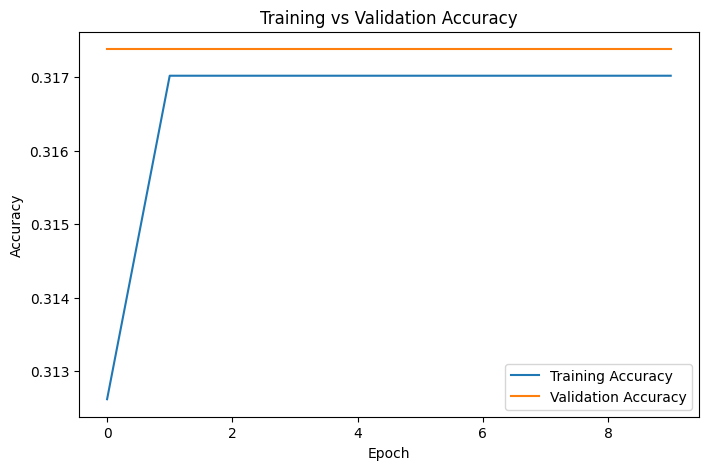

In [41]:
# import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

This plot indicates the model underfitting becasue training and validation accuracies reamin low and stop improving. Therefore the model was unable to learn contextual information for emotional detection which is learding to poor classification.

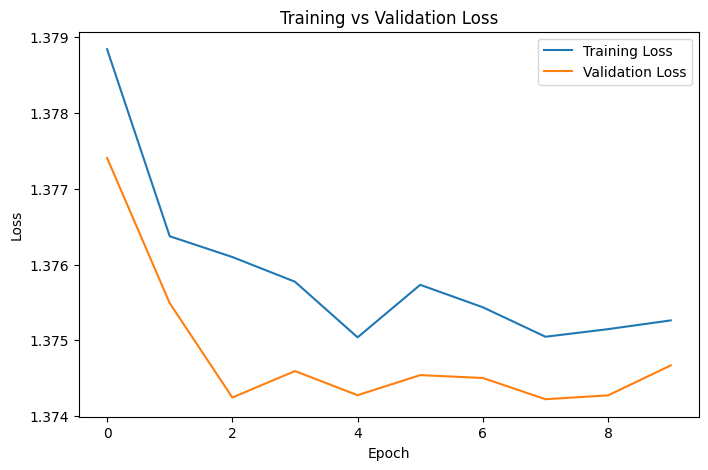

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

The loss values remained relatively high and showed little improvement, indicating that the model was underfitting the dataset.

### Build Early Stopping + BiLSTM

In the previous LSTM model training, the training and validation curves indicated that the model converged very early. Therefore, EarlyStopping was applied to prevent unnecessary training epochs and retain the model with the best validation performance.

In [43]:


# num_classes = len(np.unique(y_train))

biLSTM_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128)
    ),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

biLSTM_model.compile( optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"] )

early_stop = EarlyStopping( monitor="val_loss", patience=3, restore_best_weights=True )



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Train biLSTM_model

In [44]:
history = biLSTM_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.3955 - loss: 1.2998 - val_accuracy: 0.5510 - val_loss: 1.0640
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.7601 - loss: 0.6197 - val_accuracy: 0.8424 - val_loss: 0.4903
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9306 - loss: 0.2303 - val_accuracy: 0.8705 - val_loss: 0.4046
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.9588 - loss: 0.1320 - val_accuracy: 0.8677 - val_loss: 0.4592
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9632 - loss: 0.1091 - val_accuracy: 0.8712 - val_loss: 0.4327
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.9674 - loss: 0.0912 - val_accuracy: 0.8726 - val_loss: 0.4781


In [45]:
biLSTM_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,679,630 (17.85 MB)

 Trainable params: 1,559,876 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,119,754 (11.90 MB)

### Evaluate biLSTM model performance


In [46]:
loss, accuracy = biLSTM_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8705 - loss: 0.4046
Test Accuracy: 0.8705137372016907


In [47]:
y_pred_probs = biLSTM_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
add_result("BiLSTM", y_test, y_pred)
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

       anger       0.91      0.86      0.88       340
        fear       0.88      0.90      0.89       451
         joy       0.91      0.92      0.91       323
     sadness       0.79      0.78      0.78       307

    accuracy                           0.87      1421
   macro avg       0.87      0.87      0.87      1421
weighted avg       0.87      0.87      0.87      1421



In [48]:
biLSTM_model.save("bilstm_emotion_model.keras")

import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [49]:
results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,LinearSVC,0.829188,0.829866,0.829188,0.829134
1,LogisticRegression,0.821211,0.823766,0.821211,0.820897
2,LSTM,0.317382,0.100731,0.317382,0.152927
3,BiLSTM,0.870514,0.870680,0.870514,0.870351


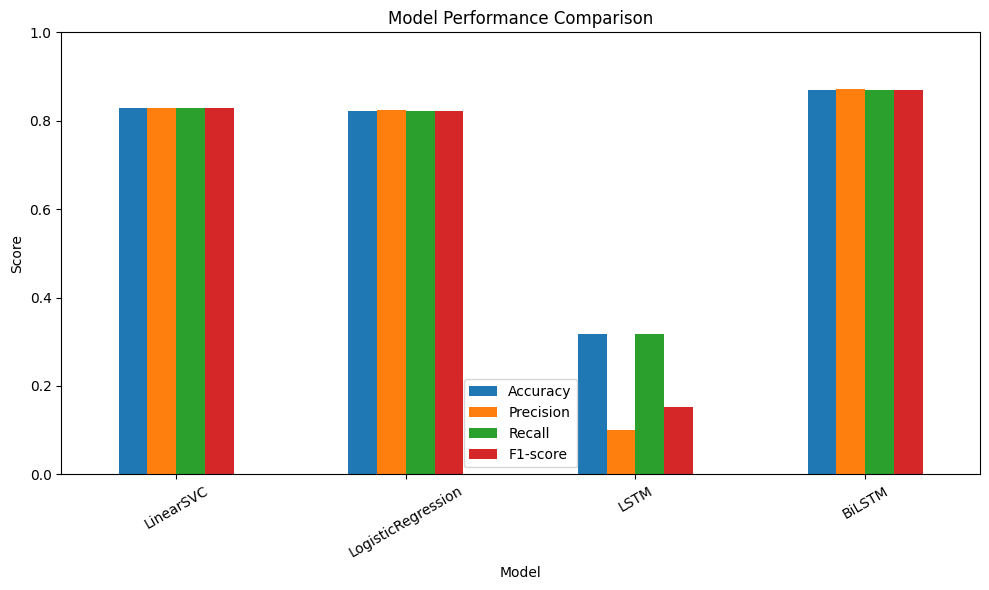

In [50]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()